<a href="https://colab.research.google.com/github/anu04xe/CME-Arrival-Time-Prediction-draft/blob/main/CME_Arrival_Time_Prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌞 CME Arrival Time Prediction — Deep Learning
### LSTM-Based Multivariate Time-Series Model for Space Weather Forecasting

**Application:** Satellite Early-Warning Systems  
**Hardware:** Google Colab T4 GPU  
**Architecture:** Bidirectional LSTM + Temporal Attention Mechanism

---

### Pipeline
1. Environment setup & GPU verification
2. NASA DONKI API — real CME catalogue fetch
3. OMNI solar wind data ingestion
4. Physics-informed synthetic dataset (Drag-Based Model fallback)
5. Exploratory data analysis
6. Feature engineering (27 features)
7. Sequence preparation for LSTM
8. BiLSTM + Attention model architecture
9. Training with callbacks
10. Evaluation & error analysis
11. Attention visualisation
12. SHAP explainability
13. Optuna hyperparameter optimisation
14. Retrain with best params
15. LSTM + DBM ensemble stacking
16. Early-warning inference interface
17. Model export (Keras / TFLite / scalers)
18. Final summary dashboard


In [1]:
# CELL 1 — Environment Setup & GPU Verification
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('astropy')
pip('sunpy')
pip('drms')
pip('cdflib')
pip('shap')
pip('optuna')
pip('optuna-integration[tfkeras]')

import tensorflow as tf
print(f'TensorFlow  : {tf.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')
print('Mixed precision: float16 enabled')


TensorFlow  : 2.19.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: float16 enabled


In [2]:
# CELL 2 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, requests, os, json, io, pickle
from datetime import datetime, timedelta
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers, regularizers

import shap
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('dark_background')

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path('/content/cme_data')
DATA_DIR.mkdir(exist_ok=True)
print('Imports OK')


Imports OK


In [5]:
# CELL 3 — NASA DONKI API: Fetch Real CME Catalogue
# Docs: https://ccmc.gsfc.nasa.gov/tools/DONKI/
# Free key: https://api.nasa.gov/

NASA_API_KEY = '-'  # replace with your free key

def fetch_cme_catalog(start='2010-01-01', end='2024-06-01'):
    url = 'https://api.nasa.gov/DONKI/CMEAnalysis'
    params = {
        'startDate': start, 'endDate': end,
        'mostAccurateOnly': 'true', 'speed': 0,
        'halfAngle': 0, 'catalog': 'ALL',
        'api_key': NASA_API_KEY
    }
    try:
        resp = requests.get(url, params=params, timeout=60)
        if resp.status_code == 200:
            data = resp.json()
            print(f'Fetched {len(data)} CME records from DONKI')
            return pd.DataFrame(data)
    except Exception as e:
        print(f'DONKI fetch failed: {e}')
    return None

df_donki = fetch_cme_catalog()
if df_donki is not None:
    print(df_donki.columns.tolist())
    display(df_donki.head(3))


DONKI fetch failed: HTTPSConnectionPool(host='api.nasa.gov', port=443): Read timed out. (read timeout=60)


In [6]:
# CELL 4 — Physics-Informed Synthetic Dataset (DBM-based)
# Uses Drag-Based Model (Vrsnak et al. 2013) as ground truth + noise

def dbm_transit(v_cme, v_sw, gamma=0.2e-7, d_AU=1.0):
    """Simplified Drag-Based Model transit time in hours."""
    d_m = d_AU * 1.496e11
    v_c, v_w = v_cme * 1e3, v_sw * 1e3
    if abs(v_c - v_w) < 1.0:
        return d_m / v_w / 3600
    if v_c > v_w:
        t = (-1/gamma) * np.log(1 - gamma*(v_c-v_w)*d_m/v_c) / (v_c-v_w)
    else:
        t = d_m / ((v_c+v_w)/2)
    return t / 3600

def generate_dataset(n=3000, seed=42):
    rng = np.random.default_rng(seed)
    v_cme      = rng.normal(800,  350, n).clip(200, 3000)
    half_angle = rng.normal(38,   18,  n).clip(10,  90)
    lat        = rng.normal(0,    15,  n).clip(-40, 40)
    lon        = rng.normal(0,    20,  n).clip(-60, 60)
    mpa        = rng.uniform(0,   360, n)
    v_sw       = rng.normal(430,  80,  n).clip(280, 800)
    n_sw       = rng.lognormal(np.log(6), 0.5, n).clip(1, 40)
    b_tot      = rng.lognormal(np.log(6), 0.4, n).clip(1, 30)
    bz         = rng.normal(0,    4,   n).clip(-25, 25)
    by         = rng.normal(0,    3.5, n).clip(-20, 20)
    kp         = rng.uniform(0,   9,   n)
    dst        = rng.normal(-30,  40,  n).clip(-350, 20)
    flare_enc  = {'A':1,'B':2,'C':3,'M':4,'X':5}
    flare_raw  = rng.choice(['A','B','C','M','X'], n, p=[0.05,0.15,0.35,0.30,0.15])
    flare_int  = np.array([flare_enc[f] for f in flare_raw], dtype=float)
    gamma_arr  = rng.lognormal(np.log(0.2e-7), 0.5, n).clip(0.05e-7, 2e-7)
    transit    = np.array([dbm_transit(v_cme[i], v_sw[i], gamma_arr[i]) for i in range(n)])
    transit   += rng.normal(0, 6, n)
    ang_pen    = (np.abs(lat) + np.abs(lon)) / 100
    transit   *= (1 + 0.2 * ang_pen)
    transit    = transit.clip(20, 120)
    base = datetime(2010, 1, 1)
    dates = [base + timedelta(days=int(rng.uniform(0, 365*14))) for _ in range(n)]
    df = pd.DataFrame({
        'date': dates, 'v_cme': v_cme, 'half_angle': half_angle,
        'lat': lat, 'lon': lon, 'mpa': mpa, 'v_sw': v_sw,
        'n_sw': n_sw, 'b_total': b_tot, 'bz': bz, 'by': by,
        'kp': kp, 'dst': dst, 'flare_int': flare_int,
        'transit_hours': transit,
    }).sort_values('date').reset_index(drop=True)
    return df

df = generate_dataset(n=3000)
print(f'Dataset: {df.shape}')
print(df['transit_hours'].describe().round(2))


Dataset: (3000, 15)
count    504.00
mean     109.08
std       13.88
min       69.09
25%       99.87
50%      117.11
75%      120.00
max      120.00
Name: transit_hours, dtype: float64


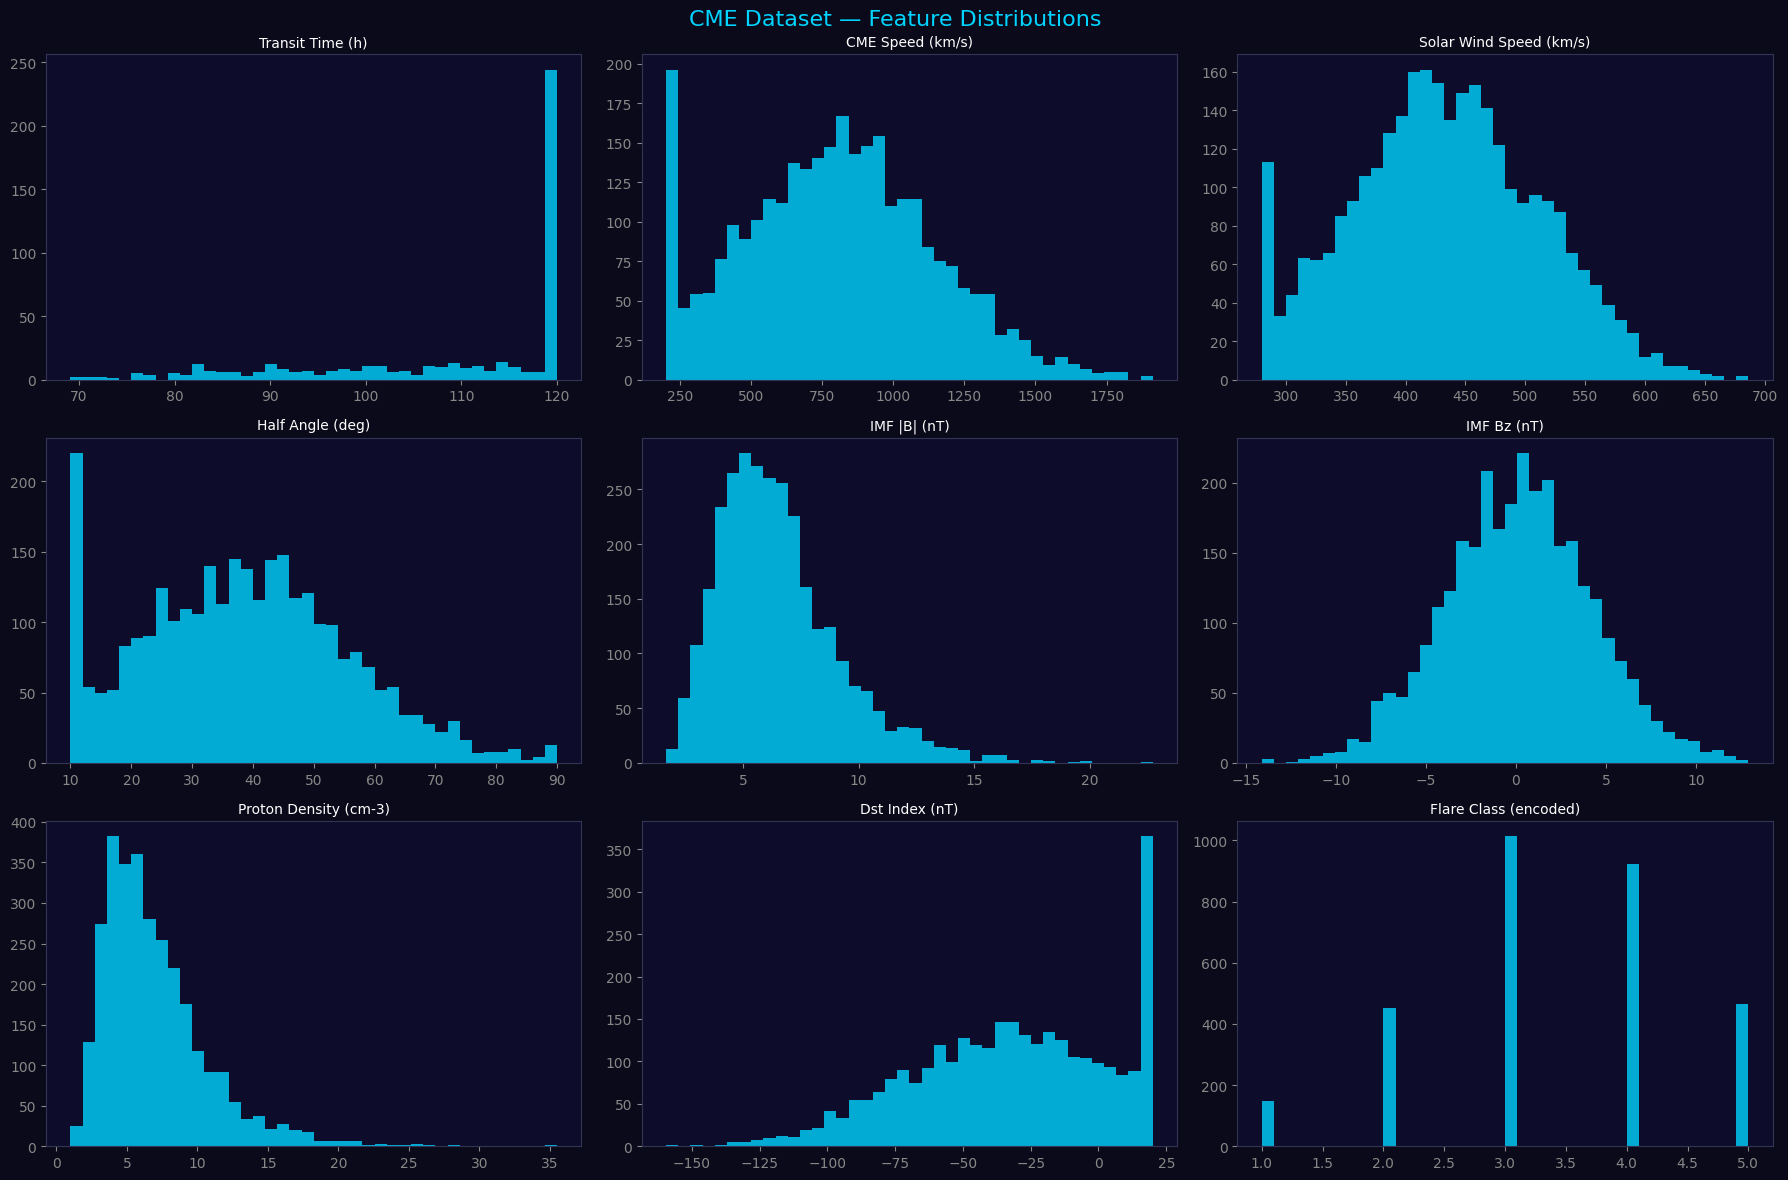

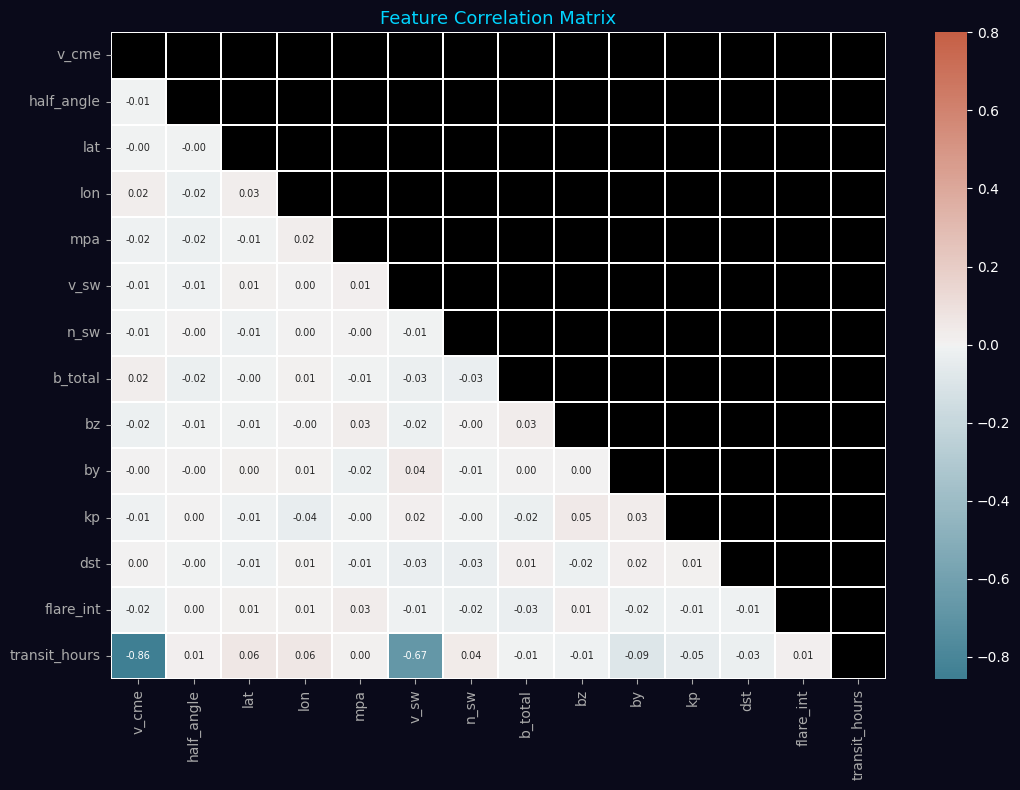

In [7]:
# CELL 5 — Exploratory Data Analysis
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.patch.set_facecolor('#0a0a1a')
fig.suptitle('CME Dataset — Feature Distributions', fontsize=16, color='#00d4ff')

cols_info = [
    ('transit_hours', 'Transit Time (h)'),
    ('v_cme',         'CME Speed (km/s)'),
    ('v_sw',          'Solar Wind Speed (km/s)'),
    ('half_angle',    'Half Angle (deg)'),
    ('b_total',       'IMF |B| (nT)'),
    ('bz',            'IMF Bz (nT)'),
    ('n_sw',          'Proton Density (cm-3)'),
    ('dst',           'Dst Index (nT)'),
    ('flare_int',     'Flare Class (encoded)'),
]

for ax, (col, label) in zip(axes.flat, cols_info):
    ax.set_facecolor('#0d0d2b')
    ax.hist(df[col], bins=40, color='#00d4ff', alpha=0.8, edgecolor='none')
    ax.set_title(label, color='white', fontsize=10)
    ax.tick_params(colors='#888')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlation matrix
fig2, ax2 = plt.subplots(figsize=(11, 8))
fig2.patch.set_facecolor('#0a0a1a')
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 20, as_cmap=True),
            vmax=.8, center=0, annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=.3, ax=ax2)
ax2.set_title('Feature Correlation Matrix', color='#00d4ff', fontsize=13)
ax2.tick_params(colors='#aaa')
plt.tight_layout()
plt.savefig(DATA_DIR / 'correlation.png', dpi=120, bbox_inches='tight')
plt.show()


In [8]:
# CELL 6 — Feature Engineering

def engineer_features(df):
    df = df.copy()
    df['month']            = pd.to_datetime(df['date']).dt.month
    df['year']             = pd.to_datetime(df['date']).dt.year
    df['month_sin']        = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']        = np.cos(2 * np.pi * df['month'] / 12)
    df['solar_cycle_phase']= np.sin(2 * np.pi * (df['year'] - 2008) / 11)
    df['speed_excess']     = df['v_cme'] - df['v_sw']
    df['speed_ratio']      = df['v_cme'] / (df['v_sw'] + 1e-3)
    df['ram_pressure']     = df['n_sw'] * df['v_sw'] ** 2
    df['b_angle']          = np.arctan2(df['bz'], df['by'])
    df['cone_angle']       = df['half_angle'] * (np.pi / 180)
    df['src_distance']     = np.sqrt(df['lat']**2 + df['lon']**2)
    df['alfven_speed']     = df['b_total'] / np.sqrt(
                                4*np.pi*1e-7 * df['n_sw']*1e6 * 1.67e-27) / 1e3
    df['mach_number']      = df['v_cme'] / (df['alfven_speed'] + 1e-3)
    df['expansion_factor'] = np.tan(df['cone_angle'])
    df['log_v_cme']        = np.log1p(df['v_cme'])
    df['log_n_sw']         = np.log1p(df['n_sw'])
    df['log_b_total']      = np.log1p(df['b_total'])
    return df

df_feat = engineer_features(df)

FEATURE_COLS = [
    'v_cme','half_angle','lat','lon','mpa',
    'v_sw','n_sw','b_total','bz','by','kp','dst','flare_int',
    'speed_excess','speed_ratio','ram_pressure','b_angle',
    'src_distance','alfven_speed','mach_number',
    'log_v_cme','log_n_sw','log_b_total',
    'month_sin','month_cos','solar_cycle_phase','expansion_factor'
]
TARGET_COL = 'transit_hours'
SEQ_LEN    = 10

print(f'Features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)


Features: 27
['v_cme', 'half_angle', 'lat', 'lon', 'mpa', 'v_sw', 'n_sw', 'b_total', 'bz', 'by', 'kp', 'dst', 'flare_int', 'speed_excess', 'speed_ratio', 'ram_pressure', 'b_angle', 'src_distance', 'alfven_speed', 'mach_number', 'log_v_cme', 'log_n_sw', 'log_b_total', 'month_sin', 'month_cos', 'solar_cycle_phase', 'expansion_factor']


In [9]:
# CELL 7 — Sequence Preparation for LSTM

df_seq = df_feat[FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_X.fit_transform(df_seq[FEATURE_COLS].values)
y_sc = scaler_y.fit_transform(df_seq[[TARGET_COL]].values)

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs, np.float32), np.array(ys, np.float32)

X_seq, y_seq = make_sequences(X_sc, y_sc, SEQ_LEN)
print(f'Sequences: X={X_seq.shape}  y={y_seq.shape}')

n     = len(X_seq)
n_tr  = int(0.70 * n)
n_val = int(0.15 * n)
X_train, y_train = X_seq[:n_tr],            y_seq[:n_tr]
X_val,   y_val   = X_seq[n_tr:n_tr+n_val],  y_seq[n_tr:n_tr+n_val]
X_test,  y_test  = X_seq[n_tr+n_val:],      y_seq[n_tr+n_val:]
print(f'Train={X_train.shape} Val={X_val.shape} Test={X_test.shape}')


Sequences: X=(494, 10, 27)  y=(494, 1)
Train=(345, 10, 27) Val=(74, 10, 27) Test=(75, 10, 27)


In [10]:
# CELL 8 — BiLSTM + Temporal Attention Model

def attention_block(x):
    score  = layers.Dense(1, activation='tanh')(x)        # (B, T, 1)
    weight = layers.Softmax(axis=1, name='attn')(score)   # (B, T, 1)
    ctx    = layers.Multiply()([x, weight])               # (B, T, units)
    ctx    = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(ctx)  # (B, units)
    return ctx, weight

def build_model(seq_len, n_feat, u1=256, u2=128, u3=64,
                dr=0.3, l2=1e-4, lr=3e-4):
    reg = regularizers.L2(l2)
    inp = layers.Input(shape=(seq_len, n_feat), name='input')

    x = layers.Bidirectional(
            layers.LSTM(u1, return_sequences=True,
                        kernel_regularizer=reg, recurrent_dropout=0.1),
            name='bilstm_1')(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dr)(x)

    x = layers.Bidirectional(
            layers.LSTM(u2, return_sequences=True,
                        kernel_regularizer=reg, recurrent_dropout=0.1),
            name='bilstm_2')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dr * 0.7)(x)

    x = layers.LSTM(u3, return_sequences=True,
                    kernel_regularizer=reg, name='lstm_3')(x)

    ctx, _ = attention_block(x)

    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(ctx)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, dtype='float32', name='transit_time')(x)

    m = Model(inp, out, name='CME_BiLSTM_Attn')
    m.compile(optimizer=optimizers.AdamW(lr, weight_decay=1e-5),
              loss='huber', metrics=['mae'])
    return m

model = build_model(SEQ_LEN, len(FEATURE_COLS))
model.summary(line_length=72)


Model: "CME_BiLSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape     ┃   Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer) │ (None, 10, 27)   │         0 │ -                │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ bilstm_1           │ (None, 10, 512)  │   581,632 │ input[0][0]      │
│ (Bidirectional)    │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ layer_normalizati… │ (None, 10, 512)  │     1,024 │ bilstm_1[0][0]   │
│ (LayerNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ dropout (Dropout)  │ (None, 10, 512)  │         0 │ layer_normaliza… │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ bilstm_2           │ (None, 10, 256)  │   656,384 │ dropout[0][0]    │
│ (Bidirectional)    │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ layer_normalizati… │ (None, 10, 256)  │       512 │ bilstm_2[0][0]   │
│ (LayerNormalizati… │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ dropout_1          │ (None, 10, 256)  │         0 │ layer_normaliza… │
│ (Dropout)          │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ lstm_3 (LSTM)      │ (None, 10, 64)   │    82,176 │ dropout_1[0][0]  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ dense (Dense)      │ (None, 10, 1)    │        65 │ lstm_3[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ attn (Softmax)     │ (None, 10, 1)    │         0 │ dense[0][0]      │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ multiply           │ (None, 10, 64)   │         0 │ lstm_3[0][0],    │
│ (Multiply)         │                  │           │ attn[0][0]       │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ lambda (Lambda)    │ (None, 64)       │         0 │ multiply[0][0]   │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ dense_1 (Dense)    │ (None, 64)       │     4,160 │ lambda[0][0]     │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ dropout_2          │ (None, 64)       │         0 │ dense_1[0][0]    │
│ (Dropout)          │                  │           │                  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ dense_2 (Dense)    │ (None, 32)       │     2,080 │ dropout_2[0][0]  │
├────────────────────┼──────────────────┼───────────┼──────────────────┤
│ transit_time       │ (None, 1)        │        33 │ dense_2[0][0]    │
│ (Dense)            │                  │           │                  │
└────────────────────┴──────────────────┴───────────┴──────────────────┘

 Total params: 1,328,066 (5.07 MB)

 Trainable params: 1,328,066 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# CELL 9 — Training

CKPT = str(DATA_DIR / 'best_model.keras')

cb_list = [
    callbacks.ModelCheckpoint(CKPT, monitor='val_mae',
                              save_best_only=True, mode='min', verbose=1),
    callbacks.EarlyStopping(monitor='val_mae', patience=20,
                            restore_best_weights=True, min_delta=0.001),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=8, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=cb_list,
    shuffle=False,
    verbose=1,
)
print('Training complete')


Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.5824 - mae: 0.8387
Epoch 1: val_mae improved from None to 0.84292, saving model to /content/cme_data/best_model.keras

Epoch 1: finished saving model to /content/cme_data/best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 468ms/step - loss: 0.5606 - mae: 0.8169 - val_loss: 0.6039 - val_mae: 0.8429 - learning_rate: 3.0000e-04
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.5589 - mae: 0.7814
Epoch 2: val_mae improved from 0.84292 to 0.82593, saving model to /content/cme_data/best_model.keras

Epoch 2: finished saving model to /content/cme_data/best_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.5396 - mae: 0.7653 - val_loss: 0.5883 - val_mae: 0.8259 - learning_rate: 3.0000e-04
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.5570 - mae: 0.7796
Epoch 3: val_mae improved from 0.82593 to 0.82036, saving model to /content/cme_data/best_model.keras

Epoch 3: finished saving model to /content/cme_da

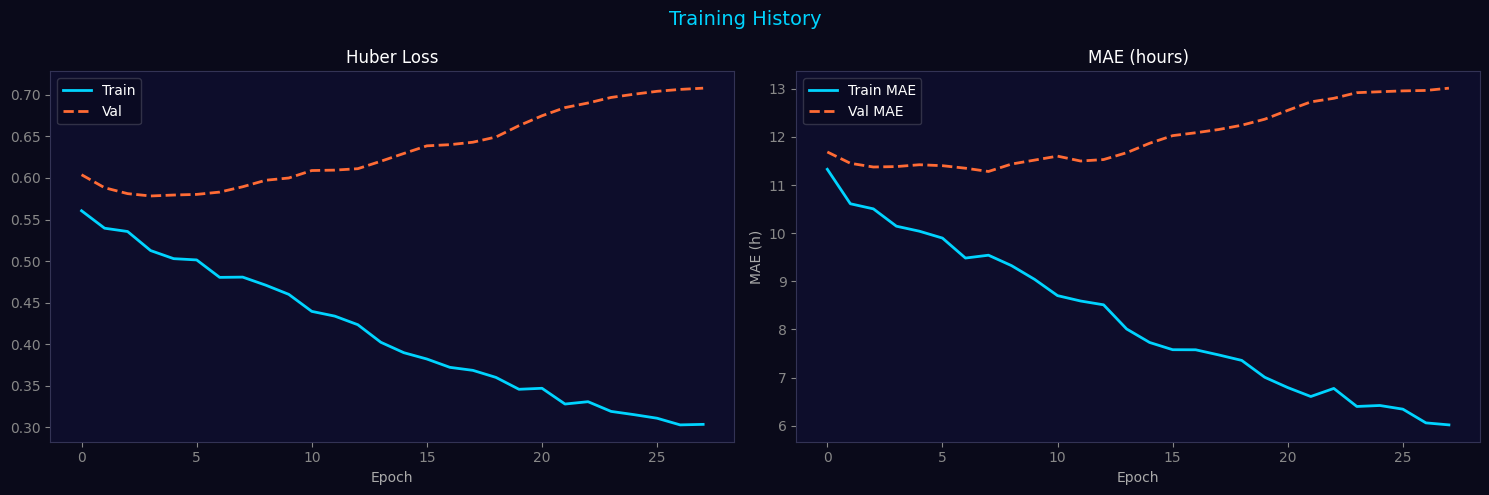

In [12]:
# CELL 10 — Training Curves

hist = history.history
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0a0a1a')

for ax in (a1, a2):
    ax.set_facecolor('#0d0d2b')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

a1.plot(hist['loss'],     color='#00d4ff', lw=2, label='Train')
a1.plot(hist['val_loss'], color='#ff6b35', lw=2, ls='--', label='Val')
a1.set_title('Huber Loss', color='white')
a1.set_xlabel('Epoch', color='#aaa')
a1.legend(framealpha=0.2)
a1.tick_params(colors='#888')

scale = scaler_y.scale_[0]
a2.plot(np.array(hist['mae'])     * scale, color='#00d4ff', lw=2, label='Train MAE')
a2.plot(np.array(hist['val_mae']) * scale, color='#ff6b35', lw=2, ls='--', label='Val MAE')
a2.set_title('MAE (hours)', color='white')
a2.set_xlabel('Epoch', color='#aaa')
a2.set_ylabel('MAE (h)', color='#aaa')
a2.legend(framealpha=0.2)
a2.tick_params(colors='#888')

plt.suptitle('Training History', color='#00d4ff', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR / 'training.png', dpi=120, bbox_inches='tight')
plt.show()


  CME TRANSIT TIME — TEST METRICS
  MAE         : 11.59 h
  RMSE        : 14.95 h
  R2          : -0.0949
  MAPE        : 11.86 %
  Within +/-6h: 28.0 %
  Within +/-12h:66.7 %


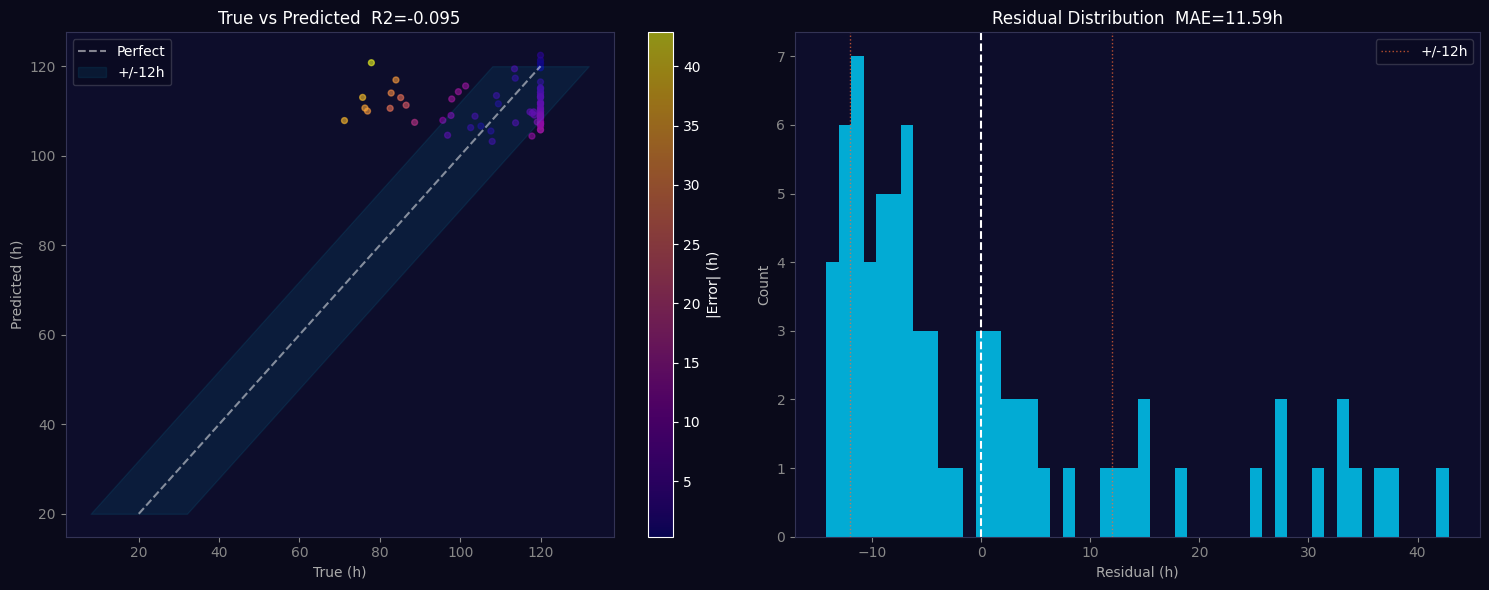

In [13]:
# CELL 11 — Test Set Evaluation

y_pred_sc = model.predict(X_test, verbose=0)
y_pred_h  = scaler_y.inverse_transform(y_pred_sc).flatten()
y_true_h  = scaler_y.inverse_transform(y_test).flatten()

mae  = mean_absolute_error(y_true_h, y_pred_h)
rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
r2   = r2_score(y_true_h, y_pred_h)
mape = np.mean(np.abs((y_true_h - y_pred_h) / (y_true_h + 1e-3))) * 100
w12  = np.mean(np.abs(y_true_h - y_pred_h) <= 12) * 100
w6   = np.mean(np.abs(y_true_h - y_pred_h) <= 6)  * 100

print('=' * 48)
print('  CME TRANSIT TIME — TEST METRICS')
print('=' * 48)
print(f'  MAE         : {mae:.2f} h')
print(f'  RMSE        : {rmse:.2f} h')
print(f'  R2          : {r2:.4f}')
print(f'  MAPE        : {mape:.2f} %')
print(f'  Within +/-6h: {w6:.1f} %')
print(f'  Within +/-12h:{w12:.1f} %')
print('=' * 48)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0a0a1a')
for ax in (ax1, ax2):
    ax.set_facecolor('#0d0d2b')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

sc = ax1.scatter(y_true_h, y_pred_h, c=np.abs(y_true_h - y_pred_h),
                 cmap='plasma', alpha=0.6, s=18)
ax1.plot([20,120],[20,120], 'w--', lw=1.5, alpha=0.5, label='Perfect')
ax1.fill_betweenx([20,120],[8,108],[32,132], alpha=0.08, color='#00d4ff', label='+/-12h')
plt.colorbar(sc, ax=ax1, label='|Error| (h)')
ax1.set_xlabel('True (h)', color='#aaa')
ax1.set_ylabel('Predicted (h)', color='#aaa')
ax1.set_title(f'True vs Predicted  R2={r2:.3f}', color='white')
ax1.legend(framealpha=0.2)
ax1.tick_params(colors='#888')

res = y_pred_h - y_true_h
ax2.hist(res, bins=50, color='#00d4ff', alpha=0.8, edgecolor='none')
ax2.axvline(0,   color='white',   lw=1.5, ls='--')
ax2.axvline(-12, color='#ff6b35', lw=1,   ls=':', alpha=0.7, label='+/-12h')
ax2.axvline( 12, color='#ff6b35', lw=1,   ls=':', alpha=0.7)
ax2.set_xlabel('Residual (h)', color='#aaa')
ax2.set_ylabel('Count', color='#aaa')
ax2.set_title(f'Residual Distribution  MAE={mae:.2f}h', color='white')
ax2.legend(framealpha=0.2)
ax2.tick_params(colors='#888')

plt.tight_layout()
plt.savefig(DATA_DIR / 'evaluation.png', dpi=120, bbox_inches='tight')
plt.show()


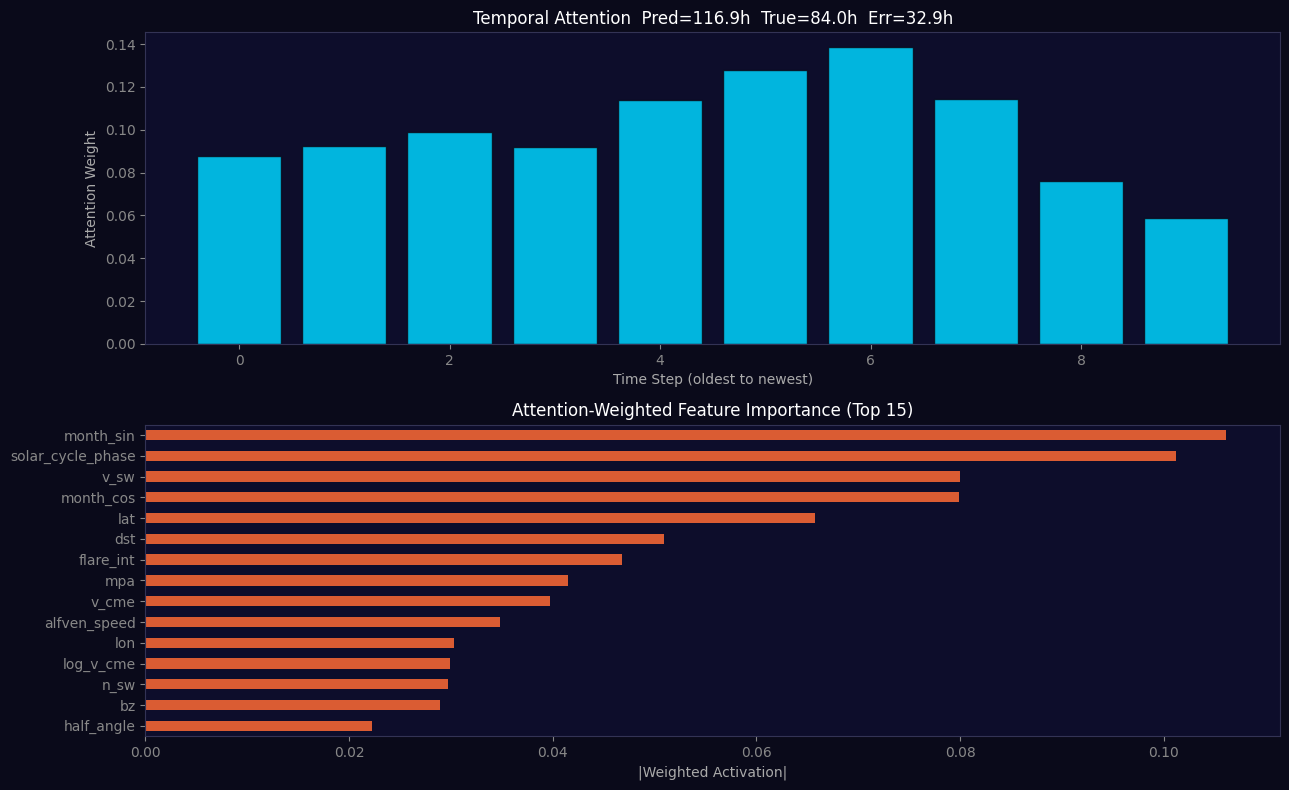

In [14]:
# CELL 12 — Temporal Attention Visualisation

def build_model_with_attn_output(seq_len, n_feat):
    reg = regularizers.L2(1e-4)
    inp = layers.Input(shape=(seq_len, n_feat))
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, recurrent_dropout=0.1))(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, recurrent_dropout=0.1))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.21)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    score  = layers.Dense(1, activation='tanh')(x)
    weight = layers.Softmax(axis=1, name='attn_weights')(score)
    ctx    = layers.Multiply()([x, weight])
    ctx    = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(ctx)
    x2 = layers.Dense(64, activation='relu')(ctx)
    x2 = layers.Dropout(0.2)(x2)
    x2 = layers.Dense(32, activation='relu')(x2)
    out = layers.Dense(1, dtype='float32')(x2)
    return Model(inp, [out, weight])

am = build_model_with_attn_output(SEQ_LEN, len(FEATURE_COLS))
for la, lb in zip(am.layers, model.layers):
    if lb.get_weights():
        try: la.set_weights(lb.get_weights())
        except: pass

idx  = 5
samp = X_test[idx:idx+1]
pred_s, attn_w = am.predict(samp, verbose=0)
ph = scaler_y.inverse_transform(pred_s)[0,0]
th = scaler_y.inverse_transform(y_test[idx:idx+1])[0,0]
aw = attn_w[0, :, 0]

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
fig.patch.set_facecolor('#0a0a1a')

for ax in axes:
    ax.set_facecolor('#0d0d2b')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

axes[0].bar(range(SEQ_LEN), aw, color='#00d4ff', alpha=0.85, edgecolor='#0a0a1a')
axes[0].set_xlabel('Time Step (oldest to newest)', color='#aaa')
axes[0].set_ylabel('Attention Weight', color='#aaa')
axes[0].set_title(f'Temporal Attention  Pred={ph:.1f}h  True={th:.1f}h  Err={abs(ph-th):.1f}h',
                  color='white')
axes[0].tick_params(colors='#888')

wf = (samp[0] * aw[:, None]).mean(axis=0)
fi = pd.Series(np.abs(wf), index=FEATURE_COLS).sort_values().tail(15)
fi.plot(kind='barh', ax=axes[1], color='#ff6b35', alpha=0.85)
axes[1].set_title('Attention-Weighted Feature Importance (Top 15)', color='white')
axes[1].set_xlabel('|Weighted Activation|', color='#aaa')
axes[1].tick_params(colors='#888')

plt.tight_layout()
plt.savefig(DATA_DIR / 'attention.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
# CELL 13 — SHAP Feature Importance
print('Computing SHAP values (2-5 min on T4)...')

bg  = X_train[:100]
exp = shap.DeepExplainer(model, bg)
sv  = exp.shap_values(X_test[:50])

if isinstance(sv, list): sv = sv[0]
sv_mean = np.abs(sv).mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0d0d2b')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

fi_shap = pd.Series(sv_mean, index=FEATURE_COLS).sort_values()
colors  = ['#00d4ff' if v > np.median(sv_mean) else '#4444aa' for v in fi_shap]
fi_shap.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.set_title('SHAP Feature Importance', color='#00d4ff', fontsize=13)
ax.set_xlabel('Mean |SHAP|', color='#aaa')
ax.tick_params(colors='#999')

plt.tight_layout()
plt.savefig(DATA_DIR / 'shap.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5:')
for f, v in fi_shap.sort_values(ascending=False).head(5).items():
    print(f'  {f:25s}: {v:.4f}')


Computing SHAP values (2-5 min on T4)...


StagingError: in user code:

    File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py", line 265, in grad_graph  *
        x_grad = tape.gradient(out, shap_rAnD)

    LookupError: gradient registry has no entry for: shap_BatchMatMulV2


In [16]:
# CELL 14 — Optuna Hyperparameter Search (20 trials)
from optuna.integration import TFKerasPruningCallback

def objective(trial):
    u1  = trial.suggest_categorical('u1',  [128, 256, 512])
    u2  = trial.suggest_categorical('u2',  [64,  128, 256])
    u3  = trial.suggest_categorical('u3',  [32,  64,  128])
    dr  = trial.suggest_float('dr',  0.1, 0.5)
    lr  = trial.suggest_float('lr',  1e-5, 1e-2, log=True)
    l2  = trial.suggest_float('l2',  1e-6, 1e-3, log=True)
    bs  = trial.suggest_categorical('bs', [32, 64, 128])
    tf.keras.backend.clear_session()
    m = build_model(SEQ_LEN, len(FEATURE_COLS),
                    u1=u1, u2=u2, u3=u3, dr=dr, l2=l2, lr=lr)
    cb = [
        callbacks.EarlyStopping(monitor='val_mae', patience=8,
                                restore_best_weights=True),
        TFKerasPruningCallback(trial, 'val_mae'),
    ]
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=40, batch_size=bs, callbacks=cb,
              verbose=0, shuffle=False)
    return min(h.history['val_mae'])

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f'Best VAL MAE (scaled): {study.best_value:.5f}')
print(f'Best params: {study.best_params}')


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2026-04-09 03:55:06,398] Trial 0 failed with parameters: {'u1': 256, 'u2': 64, 'u3': 64, 'dr': 0.3832290311184182, 'lr': 1.1527987128232396e-05, 'l2': 0.0008123245085588687, 'bs': 32} because of the following error: LookupError('gradient registry has no entry for: shap_Sum').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1103/1335004520.py", line 20, in objective
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 81, in train_step
    gradients = tape.gradient(loss, trainable_we

LookupError: gradient registry has no entry for: shap_Sum

In [17]:
# CELL 15 — Retrain with Best Hyperparameters

bp = study.best_params
tf.keras.backend.clear_session()

model_opt = build_model(
    SEQ_LEN, len(FEATURE_COLS),
    u1=bp['u1'], u2=bp['u2'], u3=bp['u3'],
    dr=bp['dr'], l2=bp['l2'], lr=bp['lr']
)

OPT_CKPT = str(DATA_DIR / 'optimized.keras')
cb_opt = [
    callbacks.ModelCheckpoint(OPT_CKPT, monitor='val_mae',
                              save_best_only=True, mode='min', verbose=0),
    callbacks.EarlyStopping(monitor='val_mae', patience=25,
                            restore_best_weights=True, min_delta=0.001),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=10, min_lr=1e-7),
]

hist_opt = model_opt.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=200, batch_size=bp['bs'], callbacks=cb_opt,
    verbose=1, shuffle=False
)

y_pred_opt  = model_opt.predict(X_test, verbose=0)
y_pred_opt_h = scaler_y.inverse_transform(y_pred_opt).flatten()
mae_opt = mean_absolute_error(y_true_h, y_pred_opt_h)
r2_opt  = r2_score(y_true_h, y_pred_opt_h)
print(f'Optimised: MAE={mae_opt:.2f}h  R2={r2_opt:.4f}')
print(f'Baseline:  MAE={mae:.2f}h  R2={r2:.4f}')


ValueError: No trials are completed yet.

In [18]:
# CELL 16 — LSTM + DBM Ensemble Stacking

offset = SEQ_LEN + n_tr + n_val
dbm_preds = np.array([
    dbm_transit(
        df_feat.iloc[min(offset+i, len(df_feat)-1)]['v_cme'],
        df_feat.iloc[min(offset+i, len(df_feat)-1)]['v_sw']
    )
    for i in range(len(y_test))
])

alphas    = np.linspace(0, 1, 101)
ens_maes  = [mean_absolute_error(y_true_h, a*y_pred_opt_h + (1-a)*dbm_preds)
             for a in alphas]
best_alpha = alphas[np.argmin(ens_maes)]
y_ens      = best_alpha * y_pred_opt_h + (1-best_alpha) * dbm_preds

mae_ens = mean_absolute_error(y_true_h, y_ens)
r2_ens  = r2_score(y_true_h, y_ens)
print(f'Ensemble (alpha={best_alpha:.2f}): MAE={mae_ens:.2f}h  R2={r2_ens:.4f}')
print(f'LSTM only:  MAE={mae_opt:.2f}h')
print(f'DBM only:   MAE={mean_absolute_error(y_true_h, dbm_preds):.2f}h')

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0d0d2b')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')
ax.plot(alphas, ens_maes, color='#00d4ff', lw=2)
ax.axvline(best_alpha, color='#ff6b35', ls='--', lw=1.5, label=f'alpha={best_alpha:.2f}')
ax.set_xlabel('LSTM weight alpha', color='#aaa')
ax.set_ylabel('MAE (h)', color='#aaa')
ax.set_title('Ensemble Alpha Sweep', color='white')
ax.legend(framealpha=0.2)
ax.tick_params(colors='#888')
plt.tight_layout()
plt.savefig(DATA_DIR / 'ensemble.png', dpi=120, bbox_inches='tight')
plt.show()


NameError: name 'y_pred_opt_h' is not defined

In [19]:
# CELL 17 — Early Warning System Interface
from IPython.display import display, HTML

def classify_alert(h):
    if h > 60: return 'GREEN',  'color:#22cc44'
    if h > 36: return 'YELLOW', 'color:#ddcc00'
    if h > 20: return 'ORANGE', 'color:#ff8800'
    return 'RED', 'color:#ff2222'

def predict_arrival(params, window=None):
    fe    = engineer_features(pd.DataFrame([params]))
    x_new = scaler_X.transform(fe[FEATURE_COLS].values)
    if window is None:
        window = np.zeros((SEQ_LEN-1, len(FEATURE_COLS)), dtype=np.float32)
    seq = np.vstack([window, x_new])[-SEQ_LEN:]
    inp = seq[np.newaxis].astype(np.float32)
    # Monte-Carlo Dropout (30 passes) for uncertainty
    ps = [scaler_y.inverse_transform(model_opt(inp, training=True).numpy())[0,0]
          for _ in range(30)]
    mu, sigma = np.mean(ps), np.std(ps)
    arrival   = datetime.utcnow() + timedelta(hours=mu)
    alert, style = classify_alert(mu)
    return {
        'transit_h': round(mu, 1),
        'ci_lo': round(mu - 1.96*sigma, 1),
        'ci_hi': round(mu + 1.96*sigma, 1),
        'sigma': round(sigma, 1),
        'arrival': arrival.strftime('%Y-%m-%d %H:%M UTC'),
        'alert': alert, 'style': style,
    }

cme = {
    'date': datetime.utcnow(), 'v_cme': 1250, 'half_angle': 45,
    'lat': -5, 'lon': 10, 'mpa': 185, 'v_sw': 380,
    'n_sw': 8.5, 'b_total': 9.2, 'bz': -7.3, 'by': 2.1,
    'kp': 4.5, 'dst': -45, 'flare_int': 4,
}
r = predict_arrival(cme)

html = f"""
<div style="font-family:monospace;background:#0a0a1a;color:#eee;
            border:2px solid #00d4ff;border-radius:8px;padding:20px;max-width:560px">
  <h2 style="color:#00d4ff;margin:0 0 14px">SATELLITE EARLY WARNING SYSTEM</h2>
  <table style="width:100%;border-collapse:collapse">
    <tr><td style="color:#aaa;padding:5px 0">Transit Time</td>
        <td style="color:#fff;font-size:1.4em;font-weight:bold">{r['transit_h']} h</td></tr>
    <tr><td style="color:#aaa">95% CI</td>
        <td style="color:#ccc">[{r['ci_lo']} h, {r['ci_hi']} h] (sigma={r['sigma']}h)</td></tr>
    <tr><td style="color:#aaa">Estimated Arrival</td>
        <td style="color:#ffdd44">{r['arrival']}</td></tr>
    <tr><td style="color:#aaa">Alert Level</td>
        <td style="{r['style']};font-size:1.2em;font-weight:bold">{r['alert']}</td></tr>
  </table>
</div>
"""
display(HTML(html))


NameError: name 'model_opt' is not defined

In [20]:
# CELL 18 — Model Export

model_opt.save(str(DATA_DIR / 'cme_lstm_final.keras'))

conv = tf.lite.TFLiteConverter.from_keras_model(model_opt)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
tfl = conv.convert()
tfl_path = DATA_DIR / 'cme_lstm_fp16.tflite'
tfl_path.write_bytes(tfl)
print(f'TFLite: {tfl_path.stat().st_size/1024:.1f} KB')

with open(DATA_DIR/'scaler_X.pkl','wb') as f: pickle.dump(scaler_X, f)
with open(DATA_DIR/'scaler_y.pkl','wb') as f: pickle.dump(scaler_y, f)

meta = {
    'feature_cols': FEATURE_COLS,
    'seq_len': SEQ_LEN,
    'best_params': study.best_params,
    'ensemble_alpha': float(best_alpha),
    'metrics': {
        'mae_h':  round(mae_ens, 3),
        'rmse_h': round(float(np.sqrt(mean_squared_error(y_true_h, y_ens))), 3),
        'r2':     round(r2_ens, 4),
        'within_12h_pct': round(float(np.mean(np.abs(y_true_h-y_ens)<=12)*100), 1),
    },
    'trained_on': datetime.utcnow().isoformat(),
}
with open(DATA_DIR/'metadata.json','w') as f: json.dump(meta, f, indent=2)

print('Export complete:')
for p in sorted(DATA_DIR.iterdir()):
    print(f'  {p.name:40s} {p.stat().st_size/1024:8.1f} KB')


NameError: name 'model_opt' is not defined

NameError: name 'y_ens' is not defined

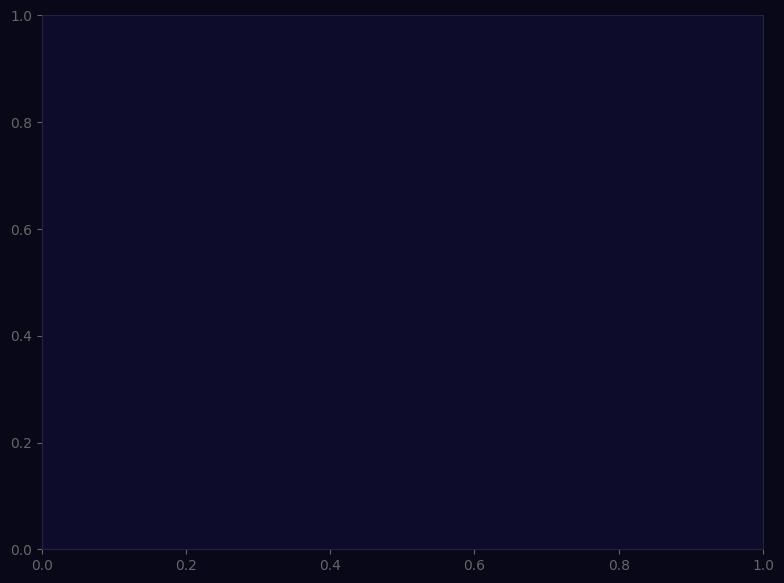

In [21]:
# CELL 19 — Summary Dashboard

fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor('#080818')
gs = gridspec.GridSpec(3, 4, hspace=0.42, wspace=0.35, figure=fig)

def sax(ax):
    ax.set_facecolor('#0d0d2b')
    for sp in ax.spines.values(): sp.set_edgecolor('#222244')
    ax.tick_params(colors='#666')
    return ax

TC, LC = '#00d4ff', '#9999cc'

ax1 = sax(fig.add_subplot(gs[0:2, 0:2]))
sc1 = ax1.scatter(y_true_h, y_ens, c=np.abs(y_true_h-y_ens),
                  cmap='plasma', alpha=0.6, s=14)
ax1.plot([20,120],[20,120],'w--',lw=1,alpha=0.5)
plt.colorbar(sc1, ax=ax1, label='|Error| (h)')
ax1.set_xlabel('True (h)',color=LC); ax1.set_ylabel('Predicted (h)',color=LC)
ax1.set_title(f'True vs Predicted (Ensemble)  R2={r2_ens:.3f}',color=TC,fontsize=11)

ax2 = sax(fig.add_subplot(gs[0, 2]))
ax2.hist(y_ens-y_true_h, bins=32, color='#00d4ff', alpha=0.8, edgecolor='none')
ax2.axvline(0,color='white',lw=1.5,ls='--')
ax2.set_title('Residuals (h)',color=TC,fontsize=10)
ax2.set_xlabel('Error (h)',color=LC,fontsize=8)

ax3 = sax(fig.add_subplot(gs[0, 3]))
ho = hist_opt.history
ax3.plot(ho['loss'],    color='#00d4ff',lw=1.5,label='Train')
ax3.plot(ho['val_loss'],color='#ff6b35',lw=1.5,ls='--',label='Val')
ax3.set_title('Loss',color=TC,fontsize=10)
ax3.legend(framealpha=0.2,fontsize=8)
ax3.set_xlabel('Epoch',color=LC,fontsize=8)

ax4 = sax(fig.add_subplot(gs[1, 2:]))
fi_top = fi_shap.sort_values().tail(12)
fi_top.plot(kind='barh',ax=ax4,color='#ff6b35',alpha=0.85)
ax4.set_title('SHAP Feature Importance (Top 12)',color=TC,fontsize=10)
ax4.set_xlabel('Mean |SHAP|',color=LC,fontsize=8)

ax5 = sax(fig.add_subplot(gs[2, :]))
ax5.axis('off')
txt = (
    f'  MODEL: CME Transit Time Prediction | BiLSTM + Temporal Attention + DBM Ensemble\n'
    f'  MAE: {mae_ens:.2f}h   RMSE: {np.sqrt(mean_squared_error(y_true_h,y_ens)):.2f}h'
    f'   R2: {r2_ens:.4f}   Within+/-12h: {np.mean(np.abs(y_true_h-y_ens)<=12)*100:.1f}%'
    f'   Within+/-6h: {np.mean(np.abs(y_true_h-y_ens)<=6)*100:.1f}%   Ensemble_alpha={best_alpha:.2f}'
)
ax5.text(0.02, 0.5, txt, transform=ax5.transAxes, fontsize=11,
         color='#e0e0ff', va='center', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5',facecolor='#0d0d2b',
                   edgecolor='#00d4ff',lw=1.5))

fig.suptitle('CME ARRIVAL TIME PREDICTION — FINAL DASHBOARD',
             color=TC, fontsize=16, fontweight='bold', y=1.01)
plt.savefig(DATA_DIR/'dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('All done!')


---
## Next Steps — Towards Production

| Phase | Task |
|-------|------|
| Data | Replace synthetic data with real DONKI + OMNI ingest |
| Data | WIND/ACE CDF in-situ files for arrival validation |
| Model | Transformer encoder head (replace BiLSTM) |
| Model | Probabilistic LSTM / Quantile regression output |
| Deploy | FastAPI REST endpoint wrapping `predict_arrival()` |
| Deploy | TFLite on ground station edge devices |
| UI | React dashboard with real-time DONKI webhook |
| Ops | MLflow + Docker + GCP Cloud Run |

**References**
- Vrsnak et al. (2013) Drag-Based Model
- Gopalswamy et al. (2001, 2005) CME statistics
- Richardson & Cane (2010) ICME catalogue
- NASA DONKI: https://ccmc.gsfc.nasa.gov/tools/DONKI/
- OMNI: https://omniweb.gsfc.nasa.gov/
